<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [52]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
%matplotlib inline

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [54]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


In [55]:
df['Industry'].value_counts()

Industry
Software Development                          11918
Other:                                         3077
Fintech                                        1641
Internet, Telecomm or Information Services     1629
Banking/Financial Services                     1371
Healthcare                                     1277
Manufacturing                                  1265
Retail and Consumer Services                   1264
Government                                      962
Media & Advertising Services                    894
Higher Education                                890
Transportation, or Supply Chain                 859
Computer Systems Design and Services            844
Energy                                          578
Insurance                                       389
Name: count, dtype: int64

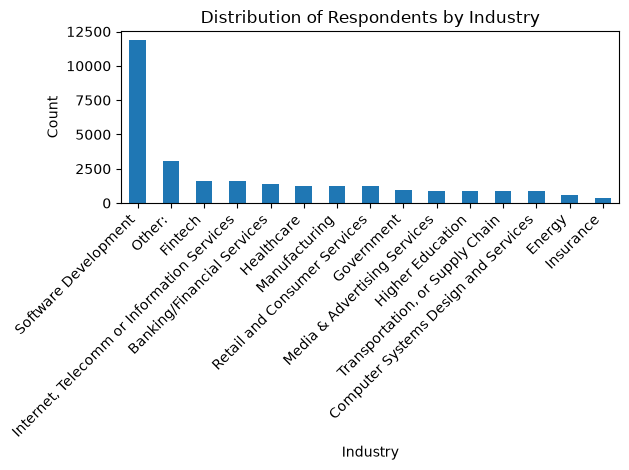

In [56]:
##Write your code here

# value counts then plot
df['Industry'].value_counts().plot(kind='bar')

plt.title('Distribution of Respondents by Industry')
plt.xlabel('Industry')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [57]:
# # In this survey sample, technology-related industries employ significantly more respondents 
# than non-tech industries"

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [58]:
df['ConvertedCompYearly'].describe()

count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

In [59]:

# 1. Basic statistics
print(df['ConvertedCompYearly'].describe())
mean_comp = df['ConvertedCompYearly'].mean()
std_comp = df['ConvertedCompYearly'].std()

print("Mean: ${:,.2f}".format(mean_comp))
print("Std Dev: ${:,.2f}".format(std_comp))


# 2. Identify > 3 standard deviations above mean
threshold = mean_comp + 3 * std_comp
print("\n3-Sigma Threshold (Mean + 3*SD): ${:,.2f}".format(threshold))

extremely_high = df[df['ConvertedCompYearly'] > threshold]

print("Found {} respondents with extremely high compensation".format(len(extremely_high)))
extremely_high.sort_values(by='ConvertedCompYearly', ascending=False)[['ConvertedCompYearly', 'Industry', 'Country']].head(10)

count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64
Mean: $86,155.29
Std Dev: $186,756.97

3-Sigma Threshold (Mean + 3*SD): $646,426.21
Found 89 respondents with extremely high compensation

,ConvertedCompYearly,Industry,Country
15837,16256603.0,NaN,Ethiopia
12723,13818022.0,Media & Advertising Services,South Africa
28379,9000000.0,Computer Systems Design and Services,Taiwan
17593,6340564.0,Software Development,Brazil
17672,4936778.0,Software Development,Ukraine
19267,3367716.0,Other:,India
23694,2584118.0,NaN,Pakistan
33720,2237846.0,NaN,Brazil
34523,2153432.0,Software Development,Pakistan
13763,2048046.0,Media & Advertising Services,Australia


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


Q1 (25th percentile): $32,712.00
Q3 (75th percentile): $107,971.50
IQR (Q3 - Q1): $75,259.50

Lower Bound (Q1 - 1.5*IQR): $-80,177.25
Upper Bound (Q3 + 1.5*IQR): $220,860.75

Number of lower outliers: 0
Number of upper outliers: 978
Total outliers: 978

/tmp/ipykernel_346/4163731676.py:35: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df['ConvertedCompYearly'].dropna(), vert=True)

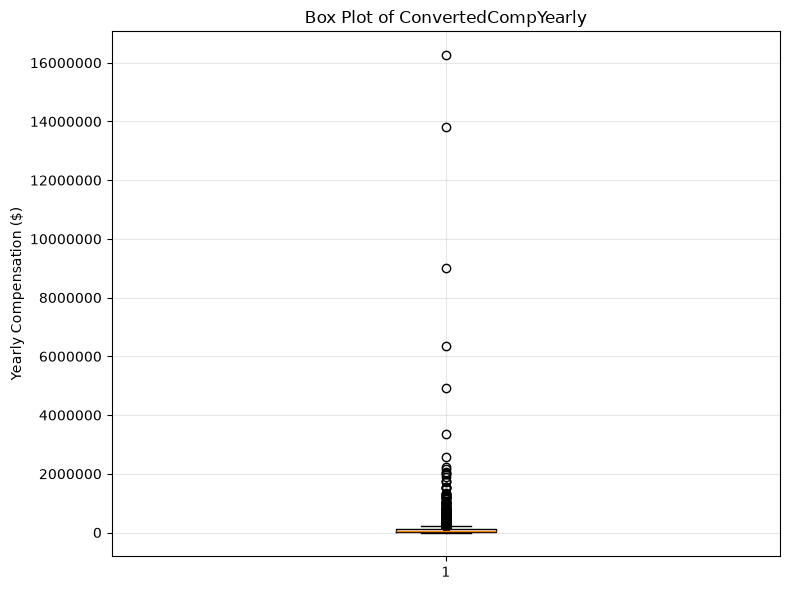


Top 10 Upper Outliers:

,ConvertedCompYearly,Industry
15837,16256603.0,NaN
12723,13818022.0,Media & Advertising Services
28379,9000000.0,Computer Systems Design and Services
17593,6340564.0,Software Development
17672,4936778.0,Software Development
19267,3367716.0,Other:
23694,2584118.0,NaN
33720,2237846.0,NaN
34523,2153432.0,Software Development
13763,2048046.0,Media & Advertising Services


In [60]:
##Write your code here
import pandas as pd
import matplotlib.pyplot as plt

file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# 1. Calculate IQR
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

print("Q1 (25th percentile): ${:,.2f}".format(Q1))
print("Q3 (75th percentile): ${:,.2f}".format(Q3))
print("IQR (Q3 - Q1): ${:,.2f}".format(IQR))

# 2. Determine upper and lower bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("\nLower Bound (Q1 - 1.5*IQR): ${:,.2f}".format(lower_bound))
print("Upper Bound (Q3 + 1.5*IQR): ${:,.2f}".format(upper_bound))

# 3. Count outliers
lower_outliers = df[df['ConvertedCompYearly'] < lower_bound]
upper_outliers = df[df['ConvertedCompYearly'] > upper_bound]
total_outliers = df[(df['ConvertedCompYearly'] < lower_bound) | (df['ConvertedCompYearly'] > upper_bound)]

print("\nNumber of lower outliers: {}".format(len(lower_outliers)))
print("Number of upper outliers: {}".format(len(upper_outliers)))
print("Total outliers: {}".format(len(total_outliers)))

# 4. Visualize with box plot
plt.figure(figsize=(8, 6))
plt.boxplot(df['ConvertedCompYearly'].dropna(), vert=True)
plt.title('Box Plot of ConvertedCompYearly')
plt.ylabel('Yearly Compensation ($)')

# to bserve data not as like 4e3 but 4000
plt.ticklabel_format(style='plain', axis='y')

#

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# show top outliers
print("\nTop 10 Upper Outliers:")
total_outliers.sort_values(by='ConvertedCompYearly', ascending=False)[['ConvertedCompYearly', 'Industry']].head(10)

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [61]:
##Write your code here
df_no_outliers = df[(df['ConvertedCompYearly'] >= lower_bound) & (df['ConvertedCompYearly'] <= upper_bound)]

print(df.shape)
print("No of NAN values is :{}".format(len(df[df['ConvertedCompYearly'].isna()])))
print("Size of data after autoremoval of NANs and after removing outliers:{}".format(df_no_outliers.shape))
#VAlidate


(65437, 114)No of NAN values is :42002
Size of data after autoremoval of NANs and after removing outliers:(22457, 114)

<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


In [69]:
import numpy as np

# Fix Years columns
years_map = {
    'Less than 1 year': 0.5,
    'More than 50 years': 55
}

for col in ['WorkExp', 'YearsCode', 'YearsCodePro']:
    if col in df.columns:
        df[col] = df[col].replace(years_map)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Fix Age
age_map = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70,
    'Prefer not to say': np.nan
}
df['AgeNumeric'] = df['Age'].map(age_map)

# Now corr will work
cols_for_corr = ['AgeNumeric', 'ConvertedCompYearly', 'WorkExp', 'YearsCode', 'YearsCodePro']

corr_matrix = df[cols_for_corr].corr()

corr_matrix.head(1)

,AgeNumeric,ConvertedCompYearly,WorkExp,YearsCode,YearsCodePro
AgeNumeric,1.0,0.121474,0.850866,0.801336,0.833744


<Axes: >

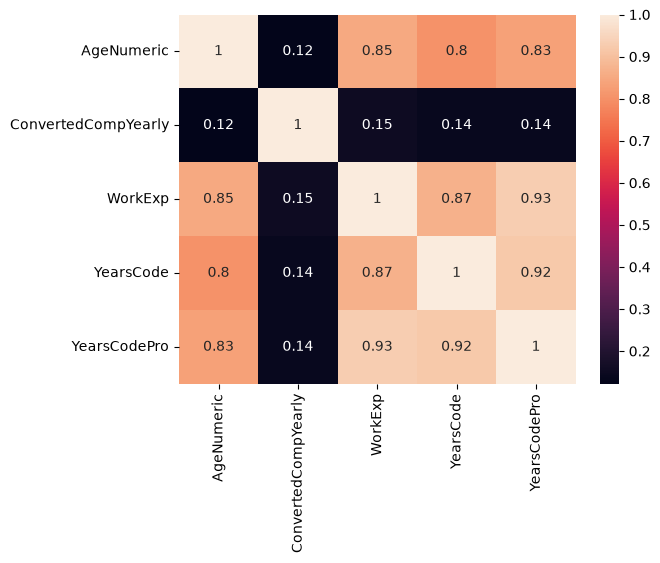

In [71]:
import seaborn as sns

sns.heatmap(corr_matrix, annot=True)

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
